Dataset source link: https://cicresearch.ca/IOTDataset/CIC_IOT_Dataset2023/browse.php?p=CSV

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import glob
import os
import numpy as np
import shutil


input_folder = r"E:\Phitron\Practise\MERGED_CSV"
temp_folder = r"E:\Phitron\Practise\GLOBAL_SHUFFLE_TEMP"
output_folder = r"E:\Phitron\Practise\FINAL_PARTS"
os.makedirs(temp_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)
files = sorted(glob.glob(os.path.join(input_folder, "*.csv")))
print("Total files:", len(files))

# Split every CSV into random chunks
chunk_size = 100000
random_state = 42
temp_files = []
print("\nCreating shuffled temporary chunks...\n")
for file_no, file in enumerate(files, start=1):
    print(f"Processing {file_no}/63: "f"{os.path.basename(file)}")
    for chunk_no, chunk in enumerate(pd.read_csv(file, chunksize=chunk_size)):
        # Shuffle this chunk
        chunk = chunk.sample(frac=1,random_state=random_state + chunk_no + file_no).reset_index(drop=True)
        temp_file = os.path.join(temp_folder,f"temp_{file_no:02d}_{chunk_no:04d}.csv")
        chunk.to_csv(temp_file,index=False)
        temp_files.append(temp_file)
    print("Done")


print("\nTemporary chunks created:", len(temp_files))
# Randomly mix the temporary chunks
rng = np.random.default_rng(42)
rng.shuffle(temp_files)
print("\nTemporary chunks randomly ordered.")

# Create final 500k parts
PART_SIZE = 500000
buffer = []
buffer_rows = 0
part_number = 1
total_written = 0

def save_part(df, part_number):
    output_file = os.path.join(
        output_folder,
        f"CIC_IoT_part{part_number:02d}.csv"
    )
    df.to_csv(output_file,index=False)
    print(f"Created Part {part_number:02d}: "f"{len(df):,} rows")
print("\nCreating final parts...\n")

for temp_file in temp_files:
    df = pd.read_csv(temp_file)
    buffer.append(df)
    buffer_rows += len(df)
    del df
    while buffer_rows >= PART_SIZE:
        combined = pd.concat(buffer,ignore_index=True)
        part = combined.iloc[:PART_SIZE].copy()
        remaining = combined.iloc[PART_SIZE:].copy()
        save_part(part,part_number)
        total_written += len(part)
        part_number += 1
        buffer = []
        if len(remaining) > 0:
            buffer.append(remaining)
        buffer_rows = len(remaining)
        del combined
        del part
        del remaining

# Save final remaining rows
if buffer_rows > 0:
    final_df = pd.concat(buffer,ignore_index=True)
    save_part(final_df,part_number)
    total_written += len(final_df)

# Delete temporary files
print("\nDeleting temporary files...")
shutil.rmtree(temp_folder)
print("Total rows written:", f"{total_written:,}")
print("Total parts:",part_number)
print("Output folder:",output_folder)

Total files: 63

Creating shuffled temporary chunks...

Processing 1/63: Merged01.csv
Done
Processing 2/63: Merged02.csv
Done
Processing 3/63: Merged03.csv
Done
Processing 4/63: Merged04.csv
Done
Processing 5/63: Merged05.csv
Done
Processing 6/63: Merged06.csv
Done
Processing 7/63: Merged07.csv
Done
Processing 8/63: Merged08.csv
Done
Processing 9/63: Merged09.csv
Done
Processing 10/63: Merged10.csv
Done
Processing 11/63: Merged11.csv
Done
Processing 12/63: Merged12.csv
Done
Processing 13/63: Merged13.csv
Done
Processing 14/63: Merged14.csv
Done
Processing 15/63: Merged15.csv
Done
Processing 16/63: Merged16.csv
Done
Processing 17/63: Merged17.csv
Done
Processing 18/63: Merged18.csv
Done
Processing 19/63: Merged19.csv
Done
Processing 20/63: Merged20.csv
Done
Processing 21/63: Merged21.csv
Done
Processing 22/63: Merged22.csv
Done
Processing 23/63: Merged23.csv
Done
Processing 24/63: Merged24.csv
Done
Processing 25/63: Merged25.csv
Done
Processing 26/63: Merged26.csv
Done
Processing 27/63:

In [ ]:
PARTS_DIR = r"E:\Phitron\Practise\FINAL_PARTS"
files = [
    os.path.join(PARTS_DIR, f"CIC_IoT_part{i:02d}.csv")
    for i in range(1, 5)
]
df = pd.concat([pd.read_csv(file) for file in files],ignore_index=True)
print("Shape:", df.shape)
OUTPUT = r"E:\Phitron\Practise\CIC_IoT_part01_04_merged.csv"
df.to_csv(OUTPUT, index=False)
print("Merged successfully!")

Shape: (2000000, 40)
Merged successfully!


In [23]:
df=pd.read_csv("../Practise/CIC_IoT_part01_04_merged.csv")

In [24]:
df.sample(10)

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
1542804,8.00,17,64.00,19201.171947,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000052,100,0.000000,DDOS-UDP_FLOOD
145036,20.00,6,64.00,59696.897239,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000017,100,0.000000,DDOS-TCP_FLOOD
1499098,19.92,6,66.55,2618.477847,0.0,0.01,0.0,0.00,0.00,0.0,...,6173,60,233,61.73,17.300000,61.73,0.000382,100,299.290000,DOS-TCP_FLOOD
91757,20.24,6,65.91,6491.022486,0.0,0.00,0.0,0.01,0.03,0.0,...,17265,66,230,172.65,16.485914,172.65,0.000156,100,271.785354,DDOS-TCP_FLOOD
1240836,0.00,1,64.00,29664.785345,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000034,100,0.000000,DDOS-ICMP_FLOOD
149863,0.00,1,64.00,31517.162609,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000032,100,0.000000,DDOS-ICMP_FLOOD
1639057,20.00,6,64.00,19801.265225,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000051,100,0.000000,DDOS-TCP_FLOOD
424218,20.00,6,64.00,31240.160882,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000032,100,0.000000,DDOS-TCP_FLOOD
1331718,0.00,1,62.72,9157.469106,0.0,0.00,0.0,0.00,0.00,0.0,...,6000,60,60,60.00,0.000000,60.00,0.000110,100,0.000000,DDOS-ICMP_FLOOD
655020,0.00,47,64.00,4349.719477,0.0,0.00,0.0,0.00,0.00,0.0,...,58706,98,592,587.06,49.400000,587.06,0.000230,100,2440.360000,MIRAI-GREETH_FLOOD


In [25]:
df.shape

(2000000, 40)

In [26]:
df.info

<bound method DataFrame.info of          Header_Length  Protocol Type  Time_To_Live          Rate  \
0                20.00              6         64.00  12716.177541   
1                20.00              6         64.00  31878.878164   
2                20.00              6         64.00   9859.902678   
3                 8.00             17         64.00  27151.113413   
4                20.00              6         64.00  37107.882863   
...                ...            ...           ...           ...   
1999995          20.00              6         64.00  25548.541146   
1999996          20.00              6         64.00  26135.992024   
1999997           8.24             17         65.73  20379.495651   
1999998          20.00              6         64.00  29020.300284   
1999999          32.00              6         61.20    996.011493   

         fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  \
0                    0.0              1.0              0.0  

In [27]:
df.describe()

c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,...,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,1.999979e+06,2.000000e+06,2.000000e+06,2.000000e+06,1.999979e+06
mean,1.373362e+01,9.092077e+00,6.654177e+01,inf,8.703772e-02,2.061099e-01,9.301019e-02,9.415764e-02,1.300942e-01,2.923565e-05,...,9.971798e-01,1.095833e+04,7.990554e+01,2.238209e+02,1.314839e+02,4.141593e+01,1.314839e+02,2.313509e-03,9.552631e+01,3.471480e+04
std,8.727393e+00,9.098086e+00,1.446654e+01,NaN,2.795072e-01,3.992432e-01,2.834184e-01,2.773915e-01,3.169623e-01,2.106635e-03,...,1.874201e-02,1.685690e+04,1.067850e+02,5.866233e+02,2.295053e+02,1.816577e+02,2.295053e+02,1.276790e+00,1.952568e+01,3.999670e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,6.452316e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,6.000000e+01,4.200000e+01,4.600000e+01,4.600000e+01,0.000000e+00,4.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,8.000000e+00,6.000000e+00,6.400000e+01,1.137778e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e+00,6.000000e+03,6.000000e+01,6.000000e+01,6.000000e+01,0.000000e+00,6.000000e+01,2.667904e-05,1.000000e+02,0.000000e+00
50%,2.000000e+01,6.000000e+00,6.400000e+01,2.461879e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e+00,6.000000e+03,6.000000e+01,6.000000e+01,6.000000e+01,0.000000e+00,6.000000e+01,4.112959e-05,1.000000e+02,0.000000e+00
75%,2.000000e+01,1.700000e+01,6.400000e+01,3.796437e+04,0.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,1.000000e-02,0.000000e+00,...,1.000000e+00,6.010000e+03,6.000000e+01,7.400000e+01,6.025000e+01,8.442318e-01,6.025000e+01,8.893967e-05,1.000000e+02,7.127273e-01
max,6.000000e+01,4.700000e+01,2.550000e+02,inf,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,2.676020e+05,4.410000e+03,2.902600e+04,7.885200e+03,8.742532e+03,7.885200e+03,1.549831e+03,1.000000e+02,7.643187e+07


In [28]:
df.isnull().sum()

Header_Length       0
Protocol Type       0
Time_To_Live        0
Rate                0
fin_flag_number     0
syn_flag_number     0
rst_flag_number     0
psh_flag_number     0
ack_flag_number     0
ece_flag_number     0
cwr_flag_number     0
ack_count           0
syn_count           0
fin_count           0
rst_count           0
HTTP                0
HTTPS               0
DNS                 0
Telnet              0
SMTP                0
SSH                 0
IRC                 0
TCP                 0
UDP                 0
DHCP                0
ARP                 0
ICMP                0
IGMP                0
IPv                 0
LLC                 0
Tot sum             0
Min                 0
Max                 0
AVG                 0
Std                21
Tot size            0
IAT                 0
Number              0
Variance           21
Label               0
dtype: int64

In [29]:
df.isnull().sum().sum()

np.int64(42)

c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


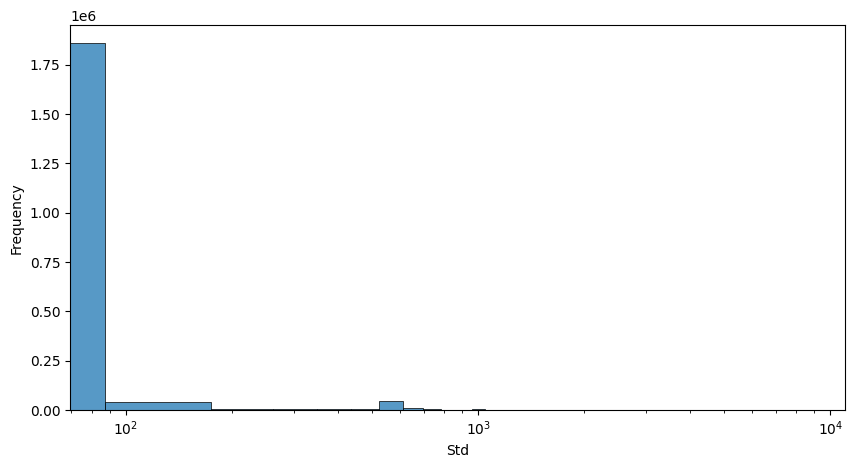

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(df["Std"], bins=100)

plt.xscale("log")
plt.ylabel("Frequency")

plt.show()

In [31]:
df["Std"].skew()

np.float64(8.69532245885256)

In [33]:
df["Std"] = df["Std"].fillna(df["Std"].mean())

c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


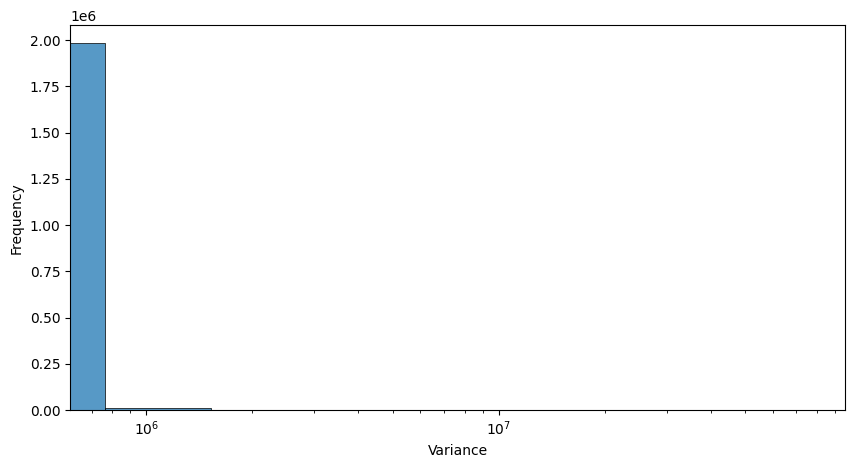

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(df["Variance"], bins=100)

plt.xscale("log")
plt.xlabel("Variance")
plt.ylabel("Frequency")

plt.show()

In [35]:
df["Variance"].skew()

np.float64(53.59562108768623)

In [36]:
df["Variance"]=df["Variance"].fillna(df["Variance"].median())

In [37]:
df.isnull().sum().sum()

np.int64(0)

In [38]:
df.duplicated().sum()

np.int64(668523)

In [39]:
df[df.duplicated(keep=False)].head(20)

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
1,20.0,6,64.0,31878.878164,1.0,0.0,1.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000031,100,0.0,DDOS-RSTFINFLOOD
2,20.0,6,64.0,9859.902678,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000101,100,0.0,DDOS-TCP_FLOOD
7,20.0,6,64.0,34047.438915,1.0,0.0,1.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000029,100,0.0,DDOS-RSTFINFLOOD
8,0.0,1,64.0,22790.176049,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000044,100,0.0,DDOS-ICMP_FLOOD
10,20.0,6,64.0,43383.367811,1.0,0.0,1.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000023,100,0.0,DDOS-RSTFINFLOOD
12,0.0,1,64.0,29886.732222,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000033,100,0.0,DDOS-ICMP_FLOOD
17,0.0,1,64.0,49825.421715,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000020,100,0.0,DDOS-ICMP_FLOOD
20,20.0,6,64.0,43387.855591,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000023,100,0.0,DDOS-TCP_FLOOD
25,0.0,1,64.0,43590.771149,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000023,100,0.0,DDOS-ICMP_FLOOD
26,0.0,1,64.0,14718.921954,0.0,0.0,0.0,0.0,0.0,0.0,...,6000,60,60,60.0,0.0,60.0,0.000068,100,0.0,DDOS-ICMP_FLOOD


In [40]:
df.shape

(2000000, 40)

In [41]:
dup = df[df.duplicated(keep=False)]

dup['Label'].value_counts()

Label
DDOS-ICMP_FLOOD            187155
DDOS-UDP_FLOOD             118434
DDOS-TCP_FLOOD              99721
DDOS-RSTFINFLOOD            92798
DDOS-SYNONYMOUSIP_FLOOD     78735
DDOS-PSHACK_FLOOD           78189
DDOS-SYN_FLOOD              73147
DOS-TCP_FLOOD               48155
DOS-UDP_FLOOD               42992
DOS-SYN_FLOOD               25112
MITM-ARPSPOOFING              927
MIRAI-UDPPLAIN                599
MIRAI-GREETH_FLOOD            348
MIRAI-GREIP_FLOOD             147
DNS_SPOOFING                  127
BENIGN                         59
RECON-PORTSCAN                 29
RECON-OSSCAN                   14
DDOS-ICMP_FRAGMENTATION        12
VULNERABILITYSCAN              10
RECON-HOSTDISCOVERY             8
DDOS-UDP_FRAGMENTATION          6
DDOS-ACK_FRAGMENTATION          4
Name: count, dtype: int64

In [42]:
duplicate_counts = df[df.duplicated(keep=False)]['Label'].value_counts()
total_counts = df['Label'].value_counts()

comparison = pd.DataFrame({
    'Total': total_counts,
    'Duplicate': duplicate_counts
}).fillna(0)

comparison['Duplicate_%'] = (
    comparison['Duplicate'] / comparison['Total'] * 100
)

print(comparison.sort_values('Duplicate_%', ascending=False))

                          Total  Duplicate  Duplicate_%
Label                                                  
DDOS-ICMP_FLOOD          306639   187155.0    61.034311
DDOS-RSTFINFLOOD         172257    92798.0    53.871831
DDOS-TCP_FLOOD           191295    99721.0    52.129434
DDOS-UDP_FLOOD           230075   118434.0    51.476258
DDOS-SYNONYMOUSIP_FLOOD  153432    78735.0    51.315892
DDOS-PSHACK_FLOOD        174831    78189.0    44.722618
DOS-TCP_FLOOD            113138    48155.0    42.563065
DDOS-SYN_FLOOD           171954    73147.0    42.538702
DOS-UDP_FLOOD            141316    42992.0    30.422599
DOS-SYN_FLOOD             85988    25112.0    29.204075
MITM-ARPSPOOFING          12972      927.0     7.146161
DNS_SPOOFING               7572      127.0     1.677232
MIRAI-UDPPLAIN            37986      599.0     1.576897
MIRAI-GREETH_FLOOD        42124      348.0     0.826132
RECON-PORTSCAN             3558       29.0     0.815065
MIRAI-GREIP_FLOOD         32125      147.0     0

In [52]:
same_label_duplicates = (dup.groupby(feature_cols, dropna=False)["Label"].nunique())
print("Total duplicate groups:", len(same_label_duplicates))
print("Same-label duplicate groups:",(same_label_duplicates == 1).sum())
print("Different-label duplicate groups:",(same_label_duplicates > 1).sum())

Total duplicate groups: 151009
Same-label duplicate groups: 127408
Different-label duplicate groups: 23601


In [45]:
feature_cols = [c for c in df.columns if c != "Label"]

conflict_groups = (
    df.groupby(feature_cols, dropna=False)["Label"]
      .nunique()
)

print("Conflicting groups:",
      (conflict_groups > 1).sum())

Conflicting groups: 57178


In [46]:
conflict_keys = conflict_groups[conflict_groups > 1].index

conflict_df = (
    df.set_index(feature_cols)
      .loc[conflict_keys]
      .reset_index()
)

print(conflict_df.shape)
print(conflict_df.head(20))

(416348, 40)
    Header_Length  Protocol Type  Time_To_Live          Rate  fin_flag_number  \
0            6.40             17        102.20  32981.866792              0.0   
1            6.40             17        102.20  32981.866792              0.0   
2            7.44             17         74.82   8787.379271              0.0   
3            7.44             17         74.82   8787.379271              0.0   
4            7.68             17         71.64   8667.708204              0.0   
5            7.68             17         71.64   8667.708204              0.0   
6            7.84             17         62.72  28910.283981              0.0   
7            7.84             17         62.72  28910.283981              0.0   
8            7.84             17         67.82  16823.649272              0.0   
9            7.84             17         67.82  16823.649272              0.0   
10           7.92             17         63.36   3340.132035              0.0   
11           7.

In [47]:
feature_cols = [c for c in df.columns if c != "Label"]
df_clean = df.drop_duplicates(
    subset=feature_cols + ["Label"],
    keep="first"
)
print("Before:", len(df))
print("After :", len(df_clean))
print("Removed:", len(df) - len(df_clean))

Before: 2000000
After : 1331477
Removed: 668523


In [49]:
df = df_clean.copy()

In [50]:
df.shape

(1331477, 40)

In [54]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance'],
      dtype='object')

In [57]:
inf_count = np.isinf(df[numeric_cols]).sum()

print(inf_count[inf_count > 0])

Rate    30
dtype: int64


In [58]:
df["Rate"] = df["Rate"].replace([np.inf, -np.inf], np.nan)

In [59]:
df["Rate"] = df["Rate"].fillna(df["Rate"].median())

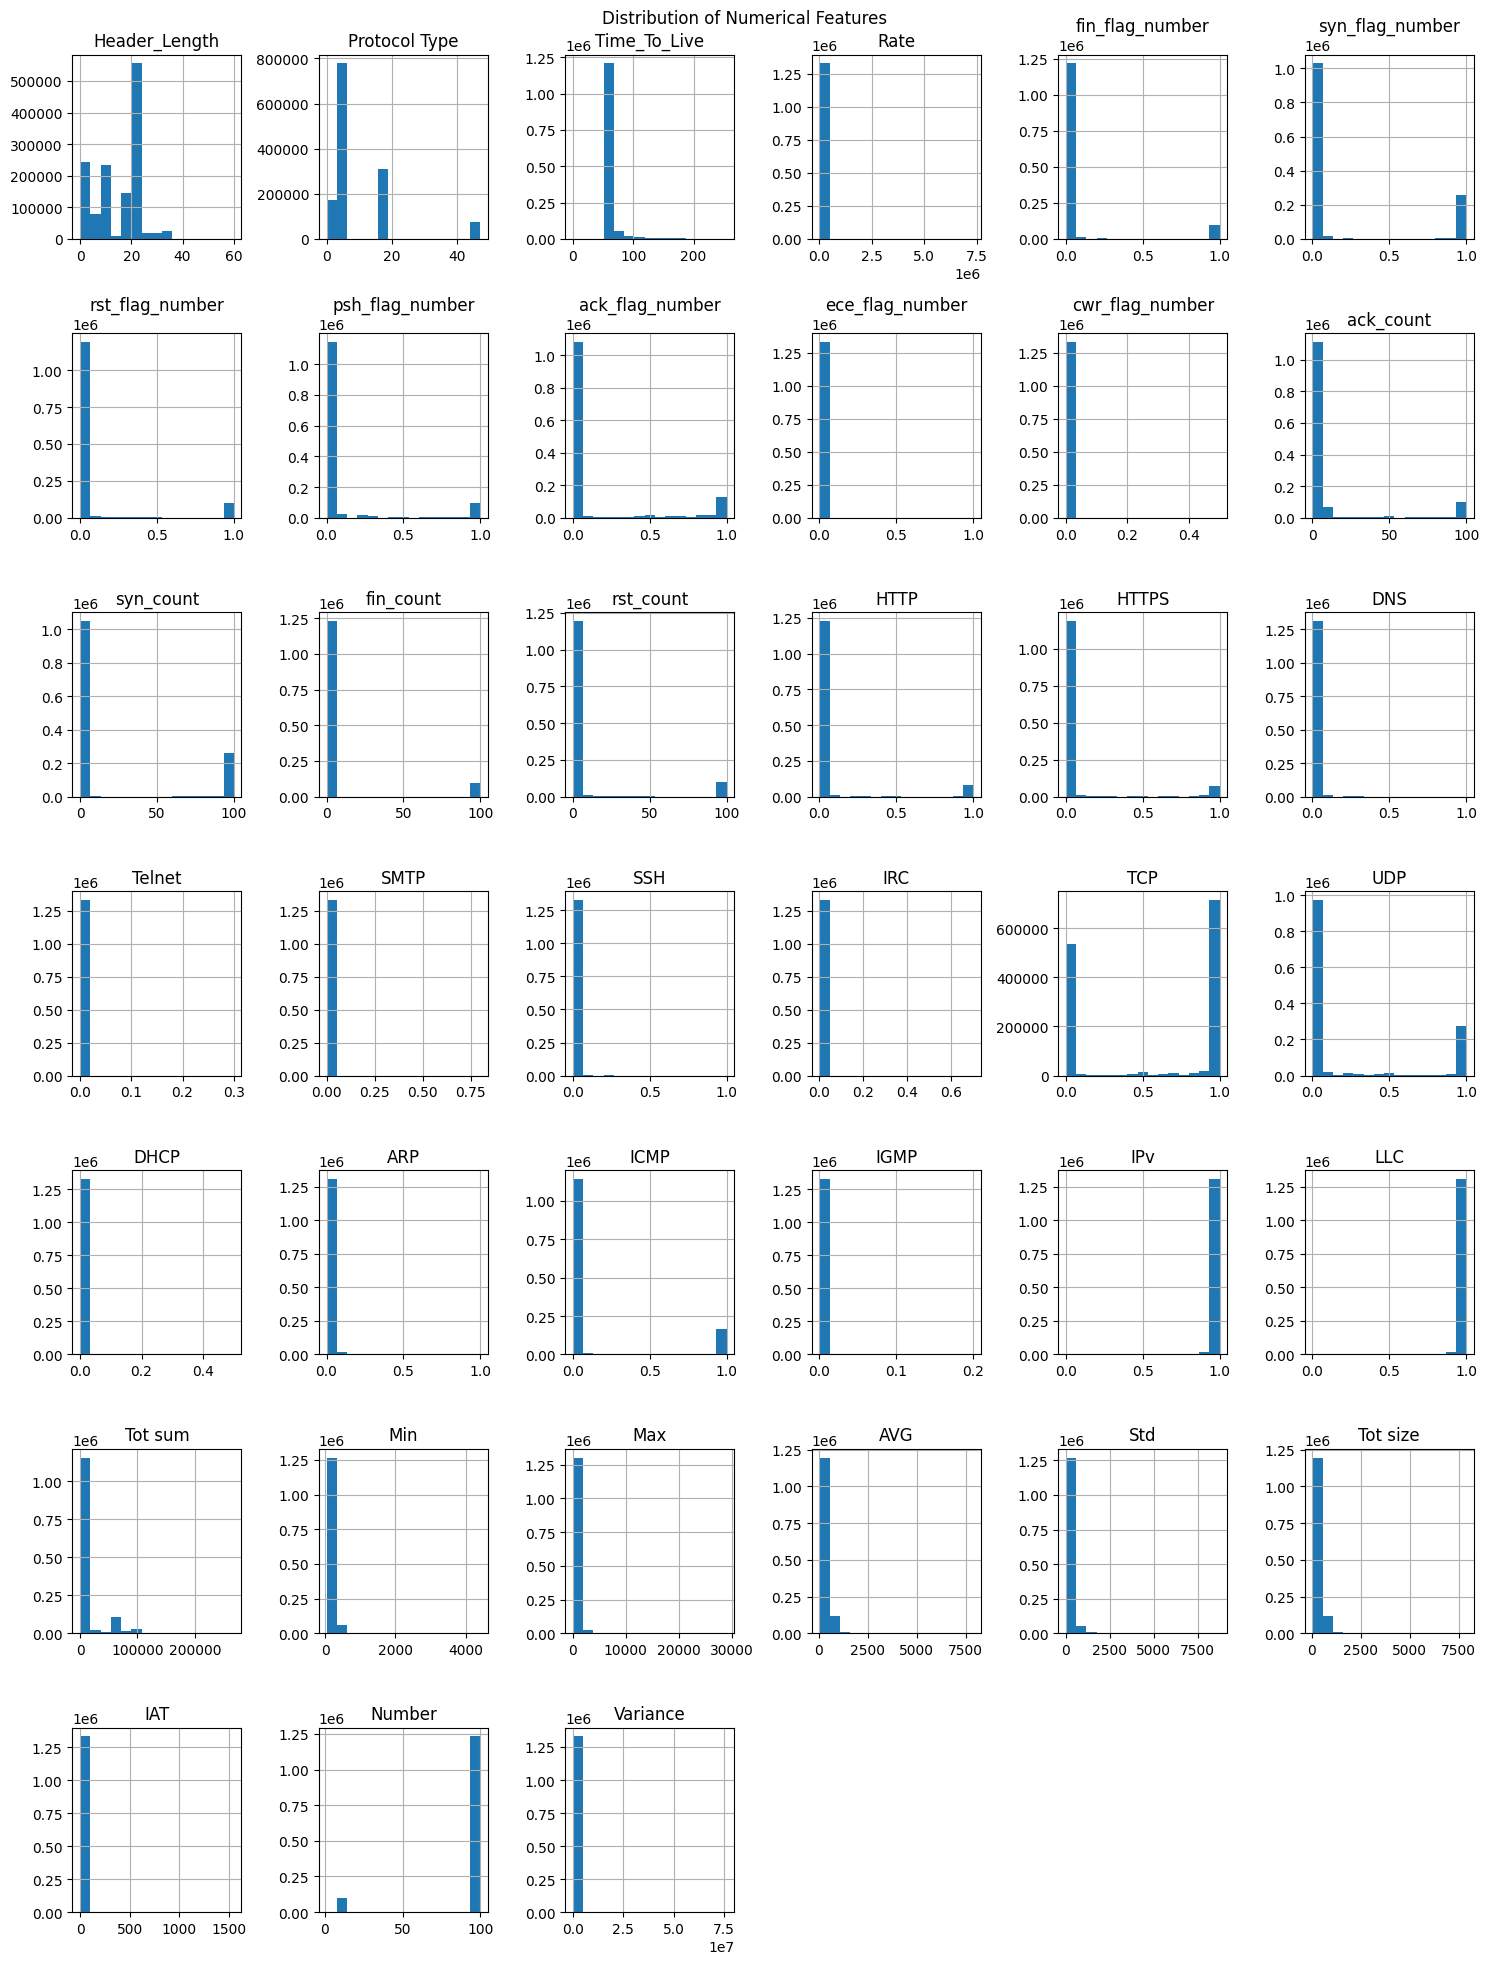

In [60]:
df[numeric_cols].hist(
    bins=15,
    figsize=(15, 20)
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

In [61]:
# Outlier Detection using IQR

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percentage": (outlier_count / len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df = outlier_df.sort_values(
    by="Outlier_Count",
    ascending=False
)

print(outlier_df.to_string(index=False))

         Column          Q1           Q3          IQR   Lower_Bound  Upper_Bound  Outlier_Count  Outlier_Percentage
   Time_To_Live   64.000000    64.000000     0.000000     64.000000    64.000000         534495           40.143014
        Tot sum 6000.000000  6124.000000   124.000000   5814.000000  6310.000000         337678           25.361159
       Variance    0.000000    39.805556    39.805556    -59.708333    99.513889         316027           23.735070
syn_flag_number    0.000000     0.010000     0.010000     -0.015000     0.025000         309007           23.207836
       Tot size   60.000000    63.060000     3.060000     55.410000    67.650000         307743           23.112904
            AVG   60.000000    63.060000     3.060000     55.410000    67.650000         307743           23.112904
            UDP    0.000000     0.200000     0.200000     -0.300000     0.500000         296466           22.265950
      syn_count    0.000000     1.000000     1.000000     -1.500000     

In [62]:
continuous_cols = [
    "Header_Length",
    "Rate",
    "Time_To_Live",
    "Tot sum",
    "Min",
    "Max",
    "AVG",
    "Std",
    "Tot size",
    "IAT",
    "Number",
    "Variance"
]

skewness = df[continuous_cols].skew().sort_values(ascending=False)

print(skewness)

IAT              829.273361
Variance          43.873495
Rate              41.417878
Max                7.532757
Std                7.101153
Min                6.364200
Time_To_Live       6.357730
AVG                3.722650
Tot size           3.722650
Tot sum            2.702667
Header_Length     -0.226566
Number            -3.255389
dtype: float64


In [63]:
import numpy as np

transform_cols = [
    "IAT",
    "Variance",
    "Rate",
    "Max",
    "Std",
    "Min",
    "Time_To_Live",
    "AVG",
    "Tot size",
    "Tot sum",
    "Number"
]

df[transform_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
IAT,1331477.0,0.003459,1.564831,0.000000,0.000033,0.000061,0.000143,1.549831e+03
Variance,1331477.0,52139.631125,489266.527267,0.000000,0.000000,0.000000,39.805556,7.643187e+07
Rate,1331477.0,23086.868086,32675.439704,0.000645,7090.722207,16806.795961,31016.076314,7.340032e+06
Max,1331477.0,305.556227,704.808622,46.000000,60.000000,60.000000,210.000000,2.902600e+04
Std,1331477.0,62.202126,219.705628,0.000000,0.000000,0.000000,6.309164,8.742532e+03
Min,1331477.0,89.400452,129.299641,42.000000,60.000000,60.000000,60.000000,4.410000e+03
Time_To_Live,1331477.0,67.818054,17.585764,0.000000,64.000000,64.000000,64.000000,2.550000e+02
AVG,1331477.0,166.868418,274.272182,46.000000,60.000000,60.000000,63.060000,7.885200e+03
Tot size,1331477.0,166.868418,274.272182,46.000000,60.000000,60.000000,63.060000,7.885200e+03
Tot sum,1331477.0,13401.919340,20186.295899,60.000000,6000.000000,6000.000000,6124.000000,2.676020e+05


In [64]:
for col in transform_cols:
    print(f"{col}: {df[col].nunique()} unique values")

IAT: 207459 unique values
Variance: 195366 unique values
Rate: 204597 unique values
Max: 3318 unique values
Std: 184593 unique values
Min: 633 unique values
Time_To_Live: 8364 unique values
AVG: 45909 unique values
Tot size: 45909 unique values
Tot sum: 43566 unique values
Number: 100 unique values


In [65]:
from sklearn.model_selection import train_test_split

In [66]:
x = df.drop(columns=["Label"])
y = df["Label"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [67]:
x_train.shape

(1065181, 39)

In [68]:
x_test.shape

(266296, 39)

In [69]:
y_train.shape

(1065181,)

In [70]:
y_test.shape

(266296,)

In [72]:
from sklearn.preprocessing import PowerTransformer

transform_cols = [
    "IAT",
    "Variance",
    "Rate",
    "Max",
    "Std",
    "Min",
    "Time_To_Live",
    "AVG",
    "Tot size",
    "Tot sum"
]

pt = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

x_train_transformed = x_train.copy()
x_test_transformed = x_test.copy()

x_train_transformed[transform_cols] = pt.fit_transform(
    x_train[transform_cols]
)

x_test_transformed[transform_cols] = pt.transform(
    x_test[transform_cols]
)

print("Transformation completed.")
print("x_train:", x_train_transformed.shape)
print("x_test :", x_test_transformed.shape)

Transformation completed.
x_train: (1065181, 39)
x_test : (266296, 39)


In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = x_train_transformed.copy()
x_test_scaled = x_test_transformed.copy()

x_train_scaled[transform_cols] = scaler.fit_transform(
    x_train_transformed[transform_cols]
)

x_test_scaled[transform_cols] = scaler.transform(
    x_test_transformed[transform_cols]
)

print("Scaling completed.")
print("x_train:", x_train_scaled.shape)
print("x_test :", x_test_scaled.shape)

Scaling completed.
x_train: (1065181, 39)
x_test : (266296, 39)


In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# x_train_scaled = x_train_transformed.copy()
# x_test_scaled = x_test_transformed.copy()

# x_train_scaled[transform_cols] = scaler.fit_transform(
#     x_train_transformed[transform_cols]
# )

# x_test_scaled[transform_cols] = scaler.transform(
#     x_test_transformed[transform_cols]
# )

# print("Scaling completed.")
# print("x_train:", x_train_scaled.shape)
# print("x_test :", x_test_scaled.shape)

Scaling completed.
x_train: (1065181, 39)
x_test : (266296, 39)


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler

continuous_cols = [
    "IAT",
    "Variance",
    "Rate",
    "Max",
    "Std",
    "Min",
    "Time_To_Live",
    "AVG",
    "Tot size",
    "Tot sum"
]

other_cols = [c for c in x_train.columns if c not in continuous_cols]

In [76]:
continuous_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("transformer", PowerTransformer(
            method="yeo-johnson",
            standardize=False
        )),
        ("scaler", StandardScaler())
    ]
)

In [77]:
continuous_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputati

In [78]:
other_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", continuous_transformer, continuous_cols),
        ("other", other_transformer, other_cols)
    ],
    remainder="drop"
)

In [80]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

lr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [87]:
lr_pipe.fit(x_train, y_train)

c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [89]:
y_pred = lr_pipe.predict(x_test)
y_pred

array(['DDOS-ICMP_FRAGMENTATION', 'MIRAI-GREIP_FLOOD',
       'DDOS-PSHACK_FLOOD', ..., 'DNS_SPOOFING', 'DDOS-ICMP_FLOOD',
       'DOS-TCP_FLOOD'], shape=(266296,), dtype=object)

In [90]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6975395800162225

Classification Report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.01      0.11      0.02        28
                 BENIGN       0.83      0.46      0.60      9331
       BROWSERHIJACKING       0.02      0.40      0.04        48
       COMMANDINJECTION       0.03      0.33      0.05        40
 DDOS-ACK_FRAGMENTATION       0.98      0.98      0.98      2440
        DDOS-HTTP_FLOOD       0.54      0.72      0.62       240
        DDOS-ICMP_FLOOD       1.00      1.00      1.00     30189
DDOS-ICMP_FRAGMENTATION       0.97      0.98      0.98      3831
      DDOS-PSHACK_FLOOD       1.00      0.99      0.99     22897
       DDOS-RSTFINFLOOD       1.00      1.00      1.00     19954
         DDOS-SLOWLORIS       0.28      0.85      0.43       216
DDOS-SYNONYMOUSIP_FLOOD       0.43      0.74      0.55     18617
         DDOS-SYN_FLOOD       0.57      0.24      0.34     23072
         DDOS-TCP_FLOOD       0.65  

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [91]:
rf_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [85]:
rf_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuous', ...), ('other', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [92]:
y_pred = rf_pipe.predict(x_test)

In [93]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7304165289752756

Classification Report:


c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.75      0.11      0.19        28
                 BENIGN       0.76      0.92      0.83      9331
       BROWSERHIJACKING       0.62      0.17      0.26        48
       COMMANDINJECTION       0.88      0.17      0.29        40
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      2440
        DDOS-HTTP_FLOOD       0.85      0.71      0.78       240
        DDOS-ICMP_FLOOD       1.00      1.00      1.00     30189
DDOS-ICMP_FRAGMENTATION       0.99      0.98      0.99      3831
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00     22897
       DDOS-RSTFINFLOOD       1.00      1.00      1.00     19954
         DDOS-SLOWLORIS       0.71      0.90      0.80       216
DDOS-SYNONYMOUSIP_FLOOD       0.41      0.42      0.41     18617
         DDOS-SYN_FLOOD       0.45      0.44      0.44     23072
         DDOS-TCP_FLOOD       0.61      0.62      0.61     22116
         DDOS-UDP_FLOOD 

c:\Users\USER\miniconda3\envs\ai_ml\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Feature Engineering

In [94]:
x_train_fe = x_train.copy()
x_test_fe = x_test.copy()

# 1. Packet size range
x_train_fe["Size_Range"] = x_train_fe["Max"] - x_train_fe["Min"]
x_test_fe["Size_Range"] = x_test_fe["Max"] - x_test_fe["Min"]

# 2. Average / Minimum ratio
x_train_fe["AVG_Min_Ratio"] = (
    x_train_fe["AVG"] / (x_train_fe["Min"] + 1)
)

x_test_fe["AVG_Min_Ratio"] = (
    x_test_fe["AVG"] / (x_test_fe["Min"] + 1)
)

# 3. Total TCP flags
x_train_fe["Total_Flags"] = (
    x_train_fe["fin_flag_number"]
    + x_train_fe["syn_flag_number"]
    + x_train_fe["rst_flag_number"]
    + x_train_fe["psh_flag_number"]
    + x_train_fe["ack_flag_number"]
)

x_test_fe["Total_Flags"] = (
    x_test_fe["fin_flag_number"]
    + x_test_fe["syn_flag_number"]
    + x_test_fe["rst_flag_number"]
    + x_test_fe["psh_flag_number"]
    + x_test_fe["ack_flag_number"]
)

print("Before:", x_train.shape)
print("After :", x_train_fe.shape)

Before: (1065181, 39)
After : (1065181, 42)


In [95]:
continuous_cols_fe = continuous_cols + [
    "Size_Range",
    "AVG_Min_Ratio",
    "Total_Flags"
]

other_cols_fe = [
    c for c in x_train_fe.columns
    if c not in continuous_cols_fe
]

In [96]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("continuous", continuous_transformer, continuous_cols_fe),
        ("other", other_transformer, other_cols_fe)
    ],
    remainder="drop"
)

Feature Selection

In [97]:
from sklearn.feature_selection import SelectKBest, f_classif

feature_selector = SelectKBest(
    score_func=f_classif,
    k=20
)

In [98]:
x_train_selected = feature_selector.fit_transform(
    preprocessor_fe.fit_transform(x_train_fe),
    y_train
)

x_test_selected = feature_selector.transform(
    preprocessor_fe.transform(x_test_fe)
)

print("x_train:", x_train_selected.shape)
print("x_test :", x_test_selected.shape)

x_train: (1065181, 20)
x_test : (266296, 20)


Augmentation / Simulation

In [99]:
print(y_train.value_counts().sort_values())

Label
UPLOADING_ATTACK               41
RECON-PINGSWEEP                72
BACKDOOR_MALWARE              113
XSS                           128
COMMANDINJECTION              161
BROWSERHIJACKING              193
SQLINJECTION                  193
DICTIONARYBRUTEFORCE          437
DDOS-SLOWLORIS                866
DDOS-HTTP_FLOOD               960
DOS-HTTP_FLOOD               2347
RECON-PORTSCAN               2835
RECON-OSSCAN                 3230
RECON-HOSTDISCOVERY          4660
DNS_SPOOFING                 5986
DDOS-UDP_FRAGMENTATION       9734
DDOS-ACK_FRAGMENTATION       9758
MITM-ARPSPOOFING             9789
VULNERABILITYSCAN           12598
DDOS-ICMP_FRAGMENTATION     15323
MIRAI-GREIP_FLOOD           25640
MIRAI-UDPPLAIN              30143
MIRAI-GREETH_FLOOD          33556
BENIGN                      37324
DOS-SYN_FLOOD               54207
DOS-TCP_FLOOD               61574
DDOS-SYNONYMOUSIP_FLOOD     74469
DDOS-RSTFINFLOOD            79814
DOS-UDP_FLOOD               87382
DDOS-TCP

In [100]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    sampling_strategy="not majority",
    random_state=42
)

x_train_balanced, y_train_balanced = ros.fit_resample(
    x_train_selected,
    y_train
)

print("Before:", x_train_selected.shape)
print("After :", x_train_balanced.shape)

Before: (1065181, 20)
After : (4105636, 20)


In [101]:
print(y_train_balanced.value_counts())

Label
DOS-TCP_FLOOD              120754
DDOS-UDP_FLOOD             120754
VULNERABILITYSCAN          120754
DDOS-RSTFINFLOOD           120754
DDOS-ACK_FRAGMENTATION     120754
DOS-UDP_FLOOD              120754
DDOS-SYNONYMOUSIP_FLOOD    120754
MIRAI-UDPPLAIN             120754
DDOS-ICMP_FLOOD            120754
DOS-SYN_FLOOD              120754
DDOS-SYN_FLOOD             120754
DDOS-TCP_FLOOD             120754
COMMANDINJECTION           120754
DDOS-PSHACK_FLOOD          120754
DDOS-ICMP_FRAGMENTATION    120754
MIRAI-GREETH_FLOOD         120754
DNS_SPOOFING               120754
BROWSERHIJACKING           120754
MIRAI-GREIP_FLOOD          120754
BENIGN                     120754
DDOS-UDP_FRAGMENTATION     120754
RECON-PORTSCAN             120754
RECON-HOSTDISCOVERY        120754
MITM-ARPSPOOFING           120754
DOS-HTTP_FLOOD             120754
RECON-OSSCAN               120754
DDOS-HTTP_FLOOD            120754
BACKDOOR_MALWARE           120754
DICTIONARYBRUTEFORCE       120754
DDOS-SLO

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train_balanced, y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [105]:
y_pred_rf = rf_model.predict(x_test_selected)

In [106]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Macro F1:", f1_score(
    y_test,
    y_pred_rf,
    average="macro"
))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7333756421425782
Macro F1: 0.5337057787966976

Classification Report:
                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.13      0.07      0.09        28
                 BENIGN       0.69      0.71      0.70      9331
       BROWSERHIJACKING       0.09      0.15      0.11        48
       COMMANDINJECTION       0.02      0.17      0.03        40
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      2440
        DDOS-HTTP_FLOOD       0.78      0.69      0.73       240
        DDOS-ICMP_FLOOD       1.00      1.00      1.00     30189
DDOS-ICMP_FRAGMENTATION       0.98      0.99      0.98      3831
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00     22897
       DDOS-RSTFINFLOOD       1.00      1.00      1.00     19954
         DDOS-SLOWLORIS       0.63      0.81      0.71       216
DDOS-SYNONYMOUSIP_FLOOD       0.43      0.87      0.57     18617
         DDOS-SYN_FLOOD       0.58      0.20      0.30     23072
       